In [ ]:
                            #### SURVIVAL ANALYSIS SAMPLE SIZE CALCULATION ####
                           

In [19]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
pd.DataFrame.iteritems = pd.DataFrame.items
from random import gauss as rgauss
import numpy as np
import re

np.float = float
from scipy.stats.mstats import gmean

from tqdm.notebook import tqdm

import pingouin as pg

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# From doi:10.1093/neuonc/noab137, we extracted mean days of survival for n=27 orthotopic GBM models under 5-days TMZ or placebo treatment regimens. 

In [20]:
df = pd.read_excel(
    "noab137_suppl_supplementary_table_s1.xlsx",
    sheet_name=0,
    skiprows=1).set_index("Treatment (Dosage)")
df.columns

Index(['GBM PDX', 'Study Date', 'Placebo_N', 'TMZ_N',
       'Placebo_Median Survival', 'TMZ_Median Survival',
       'Placebo_Mean (SD) Survival', 'TMZ_Mean (SD) Survival'],
      dtype='object')

In [21]:
untreated = df["Placebo_Mean (SD) Survival"]
treated = df["TMZ_Mean (SD) Survival"]

In [22]:
def extract(stringlike):
    if "5 days" in stringlike:
        return True
    else:
        return False

In [23]:
def getstd(stringlike):
    pos = stringlike.find("(")
    return stringlike[pos+1:-1]

In [24]:
def getave(stringlike):
    pos = stringlike.find("(")
    return stringlike[:pos - 1]

In [25]:
untreated_std = list(untreated.loc[untreated.index.map(extract)].map(getstd))
untreated_std = [float(x) for x in untreated_std]
untreated_ave = list(untreated.loc[untreated.index.map(extract)].map(getave))
untreated_ave = [float(x) for x in untreated_ave]

In [26]:
treated_std = list(treated.loc[treated.index.map(extract)].map(getstd))
treated_std = [float(x) for x in treated_std]
treated_ave = list(treated.loc[treated.index.map(extract)].map(getave))
treated_ave = [float(x) for x in treated_ave]

In [27]:
extracted = pd.DataFrame({"untreated_ave": untreated_ave, 
                          "untreated_std": untreated_std, 
                          "treated_ave": treated_ave, 
                          "treated_std": treated_std},
                          index=untreated.loc[untreated.index.map(extract)].index)

In [28]:
extracted

,untreated_ave,untreated_std,treated_ave,treated_std
Treatment (Dosage),,,,
TMZ (50 mg/kg) -- 5 days/1 week (F-Tu),61.4,70.5,104.3,85.1
TMZ (66 mg/kg) -- 5 days (M-F),45.9,13.4,277.7,83.1
TMZ (50 mg/kg) -- 5 days (M-F),31.2,10.7,33.1,8.6
TMZ (66 mg/kg) -- 5 days (M-F),58.6,7.7,116.9,19.5
TMZ (66 mg/kg) -- 5 days (M-F),38.1,15.0,92.1,27.1
TMZ (66 mg/kg) -- 5 days (M-F),15.1,1.9,52.9,3.1
TMZ (66 mg/kg) -- 5 days (M-F),26.2,6.6,54.7,4.1
TMZ (50 mg/kg) -- 5 days (M-F),15.2,1.1,80.8,27.9
TMZ (66 mg/kg) -- 5 days (M-F),65.6,41.7,237.1,82.1


In [29]:
#measure % of standard deviation
extracted["untreated_%std"] = extracted["untreated_std"] / extracted["untreated_ave"] * 100
extracted["treated_%std"] = extracted["treated_std"] / extracted["treated_ave"] * 100

In [30]:
mean_untreated_ave = extracted["untreated_ave"].mean()
mean_untreated_std = extracted["untreated_%std"].mean()
print(mean_untreated_ave)
print(mean_untreated_std)

41.84074074074074
28.036621393734368


In [31]:
mean_treated_ave = extracted["treated_ave"].mean()
mean_treated_std = extracted["treated_%std"].mean()
print(mean_treated_ave)
print(mean_treated_std)

110.24814814814815
27.514983209066465


In [32]:
def mgauss(mu=1, sigma=.1, threshold=2):
    """This limits the generated values within ± <threshold> standard deviations
    """
    
    val = mu + sigma * threshold * 2

    while abs(val - mu) > sigma * threshold: 
        val = rgauss(mu, sigma)

    return val

In [ ]:
# After data extraction, we end up with:
# mean days of survival untreated = 40
# mean days of survival TMZ = 110
# standard deviation ays of survival = 28

In [33]:
# params 

survival_std = 0.25        # % standard deviation of days of survival

survival_high = 40         # mean days of survival of untreated orthotopic GBM mice (e.g. SEMA6Ahigh)
survival_high_tmz = 110    # mean days ofsurvival of TMZ-treated orthotopic GBM mice (e.g. SEMA6Ahigh; +175% vs untreated)
survival_low = 60          # expected mean days of survival of untreated orthotopic GBM mice SEMA6A low (+30% vs SEMA6Ahigh)
survival_low_tmz = 165     # expected mean days of survival of TMZ-treated orthotopic GBM mice SEMA6A low (+175% vs untreated)

<Axes: >

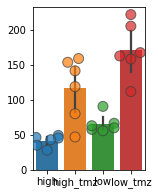

In [34]:
#plot an example

n = 6 # numerosity per experimental group

high     = [mgauss(mu=survival_high,     sigma=survival_std * survival_high,     threshold=3) for _ in range(n)]
high_tmz = [mgauss(mu=survival_high_tmz, sigma=survival_std * survival_high_tmz, threshold=3) for _ in range(n)]
low      = [mgauss(mu=survival_low,      sigma=survival_std * survival_low,      threshold=3) for _ in range(n)]
low_tmz  = [mgauss(mu=survival_low_tmz,  sigma=survival_std * survival_low_tmz,  threshold=3) for _ in range(n)]

repack = {"high": high, "high_tmz": high_tmz, "low": low, "low_tmz": low_tmz}
repack = pd.DataFrame(repack, index=range(n))

plt.figure(figsize=(2,3))
sns.barplot(data=repack)
sns.swarmplot(data=repack, s=10, linewidth=1, alpha=.7)

In [35]:
n_values = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
t_power = []
a_power1 = []
a_power2 = []
a_power3 = []

#compute p-values for ttest and Tukey's post-hoc test over 1000 simulations
for n in n_values:
    t_pvals = []
    a_pvals1 = []
    a_pvals2 = []
    a_pvals3 = []
 

    n_sims = 1000
    for i in tqdm(range(n_sims)):
        high     = [mgauss(mu=survival_high,     sigma=survival_std * survival_high,     threshold=3) for _ in range(n)]
        high_tmz = [mgauss(mu=survival_high_tmz, sigma=survival_std * survival_high_tmz, threshold=3) for _ in range(n)]
        low      = [mgauss(mu=survival_low,      sigma=survival_std * survival_low,      threshold=3) for _ in range(n)]
        low_tmz  = [mgauss(mu=survival_low_tmz,  sigma=survival_std * survival_low_tmz,  threshold=3) for _ in range(n)]
    
        t_res = pg.ttest(high, low)
        t_pval = t_res["p-val"].iloc[0]
        t_pvals.append(t_pval)

        repacked_vals = high + high_tmz + low + low_tmz
        repacked_hues = ["high" for _ in range(n)] + ["high_tmz" for _ in range(n)] + ["low" for _ in range(n)] + ["low_tmz" for _ in range(n)]
        repack = {"vals": repacked_vals, "tags": repacked_hues}
        repack = pd.DataFrame(repack, index=range(n * 4))
        #a_res = pg.anova(data=repack, dv='vals', between='tags', detailed=False)
        posthoc = pg.pairwise_tests(data=repack, dv='vals', between='tags', parametric=True, padjust='fdr_bh', effsize='hedges')
        a_pval1 = posthoc[(posthoc["A"] == "high") &  (posthoc["B"] == "low")]["p-corr"].iloc[0]
        a_pval2 = posthoc[(posthoc["A"] == "high_tmz") &  (posthoc["B"] == "low_tmz")]["p-corr"].iloc[0]
        a_pval3 = posthoc[(posthoc["A"] == "high") &  (posthoc["B"] == "high_tmz")]["p-corr"].iloc[0]
        a_pvals1.append(a_pval1)
        a_pvals2.append(a_pval2)
        a_pvals3.append(a_pval3)
        
        
    t = np.array(t_pvals)
    a1 = np.array(a_pvals1)
    a2 = np.array(a_pvals2)
    a3 = np.array(a_pvals3)
    t_pow = sum(t < .05)
    a_pow1 = sum(a1 < .05)
    a_pow2 = sum(a2 < .05)
    a_pow3 = sum(a3 < .05)
    
    t_power.append(t_pow)
    a_power1.append(a_pow1)
    a_power2.append(a_pow2)
    a_power3.append(a_pow3)
    print(f"For n = {n} the power of ttest is {sum(t < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is {sum(a1 < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between SEMA6Ahigh_tmz and SEMA6Alow_tmz is {sum(a2 < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is {sum(a3 < .05)/10}%")
    
        

  0%|          | 0/1000 [00:00<?, ?it/s]

/Users/roberto/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: divide by zero encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/Users/roberto/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6826: RuntimeWarning: divide by zero encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)


For n = 4 the power of ttest is 48.1%
For n = 4 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 43.5%
For n = 4 the power of Tukey's post-hoc test between SEMA6Ahigh_tmz and SEMA6Alow_tmz is 45.1%
For n = 4 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 94.5%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 5 the power of ttest is 59.6%
For n = 5 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 56.4%
For n = 5 the power of Tukey's post-hoc test between SEMA6Ahigh_tmz and SEMA6Alow_tmz is 55.6%
For n = 5 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 99.1%


...

For n = 13 the power of ttest is 98.0%
For n = 13 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 98.0%
For n = 13 the power of Tukey's post-hoc test between SEMA6Ahigh_tmz and SEMA6Alow_tmz is 98.3%
For n = 13 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 100.0%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 14 the power of ttest is 98.5%
For n = 14 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 98.4%
For n = 14 the power of Tukey's post-hoc test between SEMA6Ahigh_tmz and SEMA6Alow_tmz is 97.1%
For n = 14 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 100.0%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 15 the power of ttest is 98.5%
For n = 15 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 98.5%
For n = 15 the power of Tukey's post-hoc test between SEMA6Ahigh_tmz and SEMA6Alow_tmz is 98.3%
For n = 15 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 100.0%


In [36]:
posthoc

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,tags,high,high_tmz,False,True,-8.148461,28.0,two-sided,7.173678e-09,1.434736e-08,fdr_bh,1.069e+06,-2.894981
1,tags,high,low,False,True,-4.628740,28.0,two-sided,7.649384e-05,9.179261e-05,fdr_bh,263.469,-1.644496
2,tags,high,low_tmz,False,True,-11.946473,28.0,two-sided,1.655315e-12,9.931892e-12,fdr_bh,2.702e+09,-4.244337
3,tags,high_tmz,low,False,True,5.349327,28.0,two-sided,1.067992e-05,1.601988e-05,fdr_bh,1449.324,1.900506
4,tags,high_tmz,low_tmz,False,True,-3.813101,28.0,two-sided,6.920025e-04,6.920025e-04,fdr_bh,41.695,-1.354717
5,tags,low,low_tmz,False,True,-9.359893,28.0,two-sided,4.060613e-10,1.218184e-09,fdr_bh,1.537e+07,-3.325378


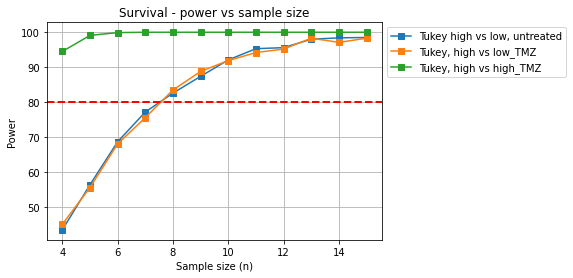

In [37]:
plt.figure()

#plt.plot(n_values, np.array(t_power)/10, marker='o', label='t-test')
plt.plot(n_values, np.array(a_power1)/10, marker='s', label='Tukey high vs low, untreated')
plt.plot(n_values, np.array(a_power2)/10, marker='s', label='Tukey, high vs low_TMZ')
plt.plot(n_values, np.array(a_power3)/10, marker='s', label='Tukey, high vs high_TMZ')

plt.xlabel('Sample size (n)')
plt.ylabel('Power')
plt.title('Survival - power vs sample size')


threshold = 80
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)

plt.show()